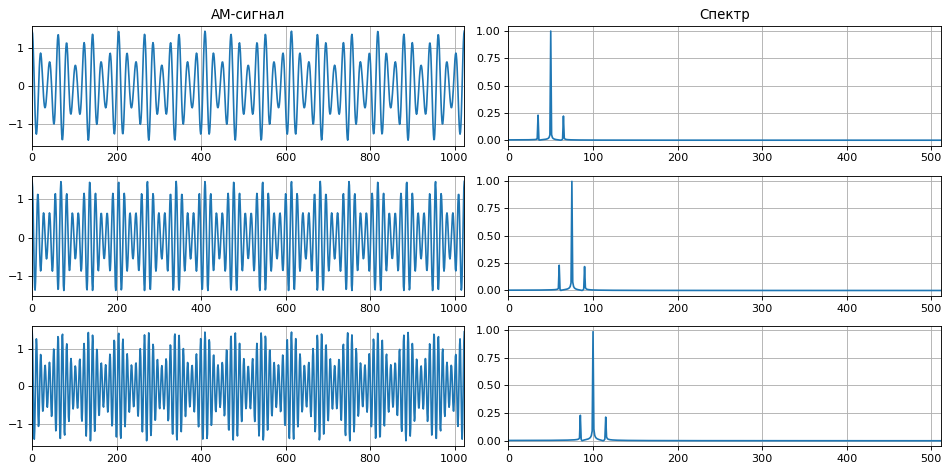

In [12]:
# построение графиков АМ-сигналов

import numpy as np
import matplotlib.pyplot as plt

# команда для отображения графиков прямо внутри ноутбука
%matplotlib inline

# функция АМ-сигнала
def signal_am(amp=1.0, km=0.25, fc=10.0, fs=2.0, period=100):
    # создаем массив времени t, равномерно распределённый от 0 до 2π
    t = 2.0 * np.pi * np.linspace(0, 1, period)
    
    # генерируем амплитудно-модулированный сигнал:
    # - основная амплитуда: 'amp'
    # - модулирующий фактор: (1 + km * cos(fs * t))
    # - несущая частота: cos(fc * t)
    return amp * (1 + km * np.cos(fs * t)) * np.cos(fc * t)

# задаем параметры сигнала
N = 1024  # число точек дискретизации (длина сигнала)
fs = 15   # частота дискретизации (сколько точек в секунду)
# ------ или ------
# fs = 60   # частота дискретизации (сколько точек в секунду)
fc = [50, 75, 100]  # список частот несущей для каждого сигнала

# создаем список сигналов для каждой частоты несущей
sig = [signal_am(amp=1.0, km=0.45, fc=i, fs=fs, period=N) for i in fc]
# для каждого значения fc вызываем функцию signal_am и собираем сигналы в список

# вычисляем БПФ (Быстрое преобразование Фурье) для каждого сигнала
# np.fft.rfft возвращает положительные частоты спектра для реальных сигналов
# делим результат на N и на 0.5 для нормализации амплитуд
sft = np.abs(np.fft.rfft(sig, axis=1)) / N / 0.5
# получаем амплитудный спектр каждого сигнала

# создаем фигуру для построения графиков
plt.figure(figsize=(12, 6), dpi=80)

# цикл по каждому сигналу и его спектру
for i, freq in enumerate(fc):
    # построение графика АМ-сигнала
    plt.subplot(len(fc), 2, 2*i+1)  # создаем подграф для сигнала
    if i == 0:
        plt.title('АМ-сигнал')  # название для первого графика
    plt.plot(sig[i])  # строим график сигнала
    plt.xlim([0, N-1])  # ограничиваем по оси X длиной сигнала
    plt.grid(True)  # включаем сетку для удобства

    # построение графика спектра
    plt.subplot(len(fc), 2, 2*i+2)  # создаем подграф для спектра
    if i == 0:
        plt.title('Спектр')  # название для первого спектра
    plt.plot(sft[i])  # строим спектр сигнала
    plt.xlim([0, N//2-1])  # ограничиваем по оси X половиной спектра
    plt.grid(True)  # включаем сетку

# улучшаем расположение графиков, чтобы не налегали друг на друга
plt.tight_layout()